# Machine Learning Models

## Baseline Linear Regression

Objective

Train a baseline regression model for Remaining Useful Life prediction.

## Load libraries and dataset

Load the prepared dataset

In [1]:
import pandas as pd
df = pd.read_csv('../data/processed/train_FD001_features.csv')

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 20631 entries, 0 to 20630
Data columns (total 91 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   unit_number                        20631 non-null  int64  
 1   time_in_cycles                     20631 non-null  int64  
 2   operational_setting_1              20631 non-null  float64
 3   operational_setting_2              20631 non-null  float64
 4   operational_setting_3              20631 non-null  float64
 5   sensor_measurement_1               20631 non-null  float64
 6   sensor_measurement_2               20631 non-null  float64
 7   sensor_measurement_3               20631 non-null  float64
 8   sensor_measurement_4               20631 non-null  float64
 9   sensor_measurement_5               20631 non-null  float64
 10  sensor_measurement_6               20631 non-null  float64
 11  sensor_measurement_7               20631 non-null  float64
 12  s

In [2]:
import os
os.makedirs("../reports/figures", exist_ok=True)

# Recreate X and y

The target is RUL, everything else other than identifiers like `unit_number` becomes our features.

## Split the data

In [ ]:
from sklearn.model_selection import GroupShuffleSplit

# 0. Drop warm up rows and leaky columns
df_model = df[df['time_in_cycles'] >= 5].reset_index(drop=True)

groups = df_model['unit_number']
x = df_model.drop(columns=['RUL', 'max_cycles', 'unit_number'])

# Cap RUL at 125 cycles. 
y = df_model['RUL'].clip(upper=RUL_CAP)

# 1. Split by engine; 80 engines train, 20 engines test
splitter = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, test_idx = next(splitter.split(x, y, groups=groups))

x_train, x_test = x.iloc[train_idx], x.iloc[test_idx]
y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

print(x_train.shape, x_test.shape)
print("train engines:", groups.iloc[train_idx].nunique(),
      "test engines:", groups.iloc[test_idx].nunique())
print("overlap:", set(groups.iloc[train_idx]) & set(groups.iloc[test_idx]))


(16241, 88) (3990, 88)
train engines: 80 test engines: 20
overlap: set()


## Import linear regression

Initialize and fit the model

In [4]:
from sklearn.linear_model import LinearRegression
model = LinearRegression()
model.fit(x_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](88,)","[ -0.14,-99.47,458.81,..., 0. , -3.63, -6.25]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](88,)","['time_in_cycles','operational_setting_1','operational_setting_2',..., 'sensor_measurement_19_change','sensor_measurement_20_change', 'sensor_measurement_21_change']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,-1.284e+05
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,88
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(63)


## Predict values for unseen test data

In [5]:
y_pred = model.predict(x_test)

## Evaluate linear regression model

Using three metrics:
- Mean absolute error
- Root mean squared error
- R² Score

In [6]:
from sklearn.metrics import mean_absolute_error, root_mean_squared_error, r2_score

results = {}

def evaluate(name, y_true, y_hat):
    """Score a model, keep the result for later comparison, and print it."""
    scores = {
        'MAE': mean_absolute_error(y_true, y_hat),
        'RMSE': root_mean_squared_error(y_true, y_hat),
        'R2': r2_score(y_true, y_hat),
    }
    results[name] = scores

    print(name)
    print(f"MAE:  {scores['MAE']:.2f} cycles")
    print(f"RMSE: {scores['RMSE']:.2f} cycles")
    print(f"R²:   {scores['R2']:.3f}")

evaluate('Linear Regression', y_test, y_pred)

Linear Regression
MAE:  14.17 cycles
RMSE: 17.65 cycles
R²:   0.821


# Plot actual vs predictions - Linear regression

Compare the predicted values to the actual values using scatter plots.

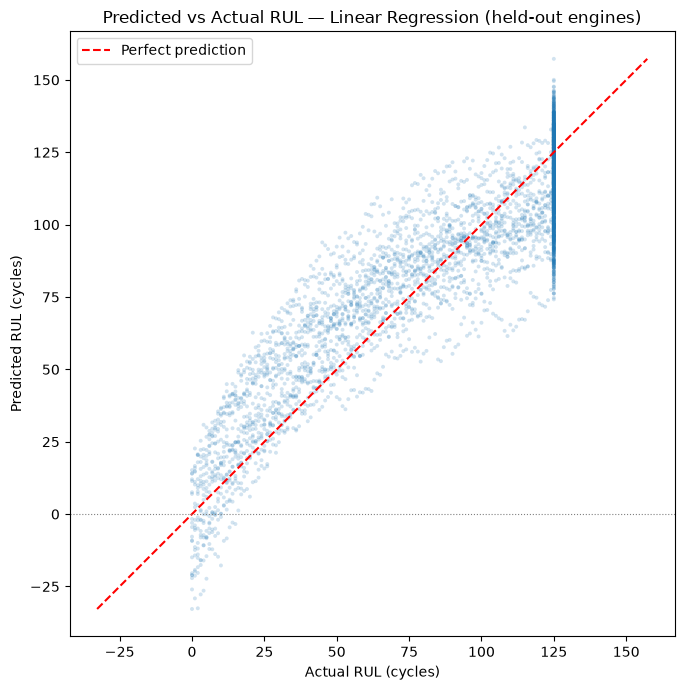

In [7]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(7, 7))

ax.scatter(y_test, y_pred, alpha=0.2, s=8, edgecolor='none')

# Perfect prediction reference line
lims = [min(y_test.min(), y_pred.min()), max(y_test.max(), y_pred.max())]
ax.plot(lims, lims, 'r--', linewidth=1.5, label='Perfect prediction')

ax.axhline(0, color='gray', linewidth=0.8, linestyle=':')

ax.set_xlabel('Actual RUL (cycles)')
ax.set_ylabel('Predicted RUL (cycles)')
ax.set_title('Predicted vs Actual RUL — Linear Regression (held-out engines)')
ax.set_aspect('equal')
ax.legend()

# Save the plot
plt.tight_layout()

plt.savefig("../reports/figures/prediction_scatter.png",
            dpi=300,
            bbox_inches="tight")

plt.show()

# Linear regression observations

- Points below the red line = the model predicts less life than the engine actually had.
- Points above the line = the model predicts more life than there was. These are the dangerous ones: the engine fails sooner than you were told.
- Predictions below zero. Linear regression is unbounded, so it will output negative RUL.


# Residual plot - Linear regression

Residuals give us a sense of the overall quality, or accuracy of the predictions made with the line.

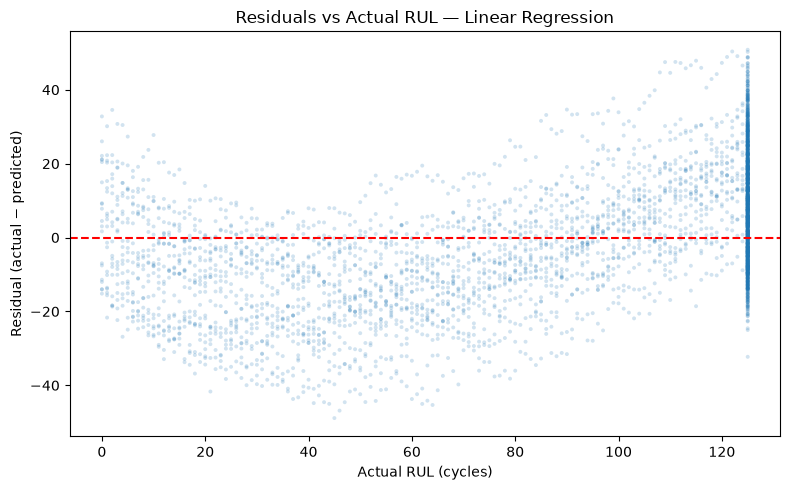

In [8]:
residuals = y_test - y_pred

fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(y_test, residuals, alpha=0.2, s=8, edgecolor='none')
ax.axhline(0, color='red', linestyle='--', linewidth=1.5)
ax.set_xlabel('Actual RUL (cycles)')
ax.set_ylabel('Residual (actual − predicted)')
ax.set_title('Residuals vs Actual RUL — Linear Regression')

# Save the plot
plt.tight_layout()

plt.savefig("../reports/figures/residual_plot.png",
            dpi=300,
            bbox_inches="tight")

plt.show()

# Save linear regression model

Later, the dashboard will load this file directly.

In [9]:
import joblib
joblib.dump(model, '../models/linear_regression_model.pkl')

['../models/linear_regression_model.pkl']

# Decision tree regression

The relationship between wear & tear vs health is often non linear. Decision trees can capture these non linear relationships.

In [10]:
from sklearn.tree import DecisionTreeRegressor

# An unconstrained tree grows until every leaf is pure, which memorises noise
# across 88 correlated features. Limiting depth and leaf size keeps it
# generalising; random_state makes the result reproducible.
decision_tree = DecisionTreeRegressor(
    max_depth=6,
    min_samples_leaf=20,
    random_state=42,
)
decision_tree.fit(x_train, y_train)

# A large train/test gap here is the signature of overfitting.
print(f"train R²: {decision_tree.score(x_train, y_train):.3f}")
print(f"test R²:  {decision_tree.score(x_test, y_test):.3f}")

train R²: 0.850
test R²:  0.832


# Predictions

In [11]:
decision_tree_pred = decision_tree.predict(x_test)

# Evaluate decision tree model

In [12]:
evaluate('Decision Tree', y_test, decision_tree_pred)

Decision Tree
MAE:  11.63 cycles
RMSE: 17.11 cycles
R²:   0.832


# Plot actual vs predictions - Decision tree

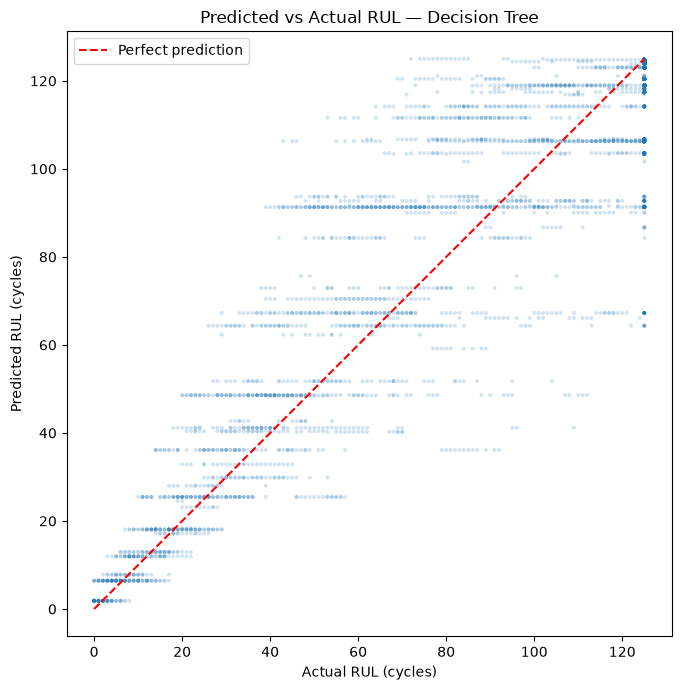

In [13]:
fig, ax = plt.subplots(figsize=(7, 7))

ax.scatter(y_test, decision_tree_pred, alpha=0.2, s=8, edgecolor='none')

# Perfect prediction reference line
lims = [min(y_test.min(), decision_tree_pred.min()), max(y_test.max(), decision_tree_pred.max())]
ax.plot(lims, lims, 'r--', linewidth=1.5, label='Perfect prediction')

ax.set_xlabel('Actual RUL (cycles)')
ax.set_ylabel('Predicted RUL (cycles)')
ax.set_title('Predicted vs Actual RUL — Decision Tree')
ax.set_aspect('equal')
ax.legend()

# Save the plot
plt.tight_layout()

plt.savefig("../reports/figures/decision_tree_predictions_scatter.png",
            dpi=300,
            bbox_inches="tight")

plt.show()

# Residual plot - Decision tree

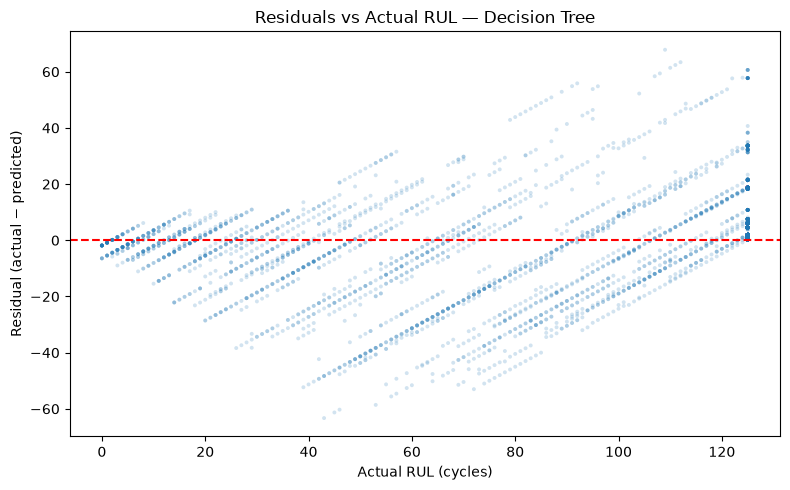

In [14]:
residuals = y_test - decision_tree_pred

fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(y_test, residuals, alpha=0.2, s=8, edgecolor='none')
ax.axhline(0, color='red', linestyle='--', linewidth=1.5)
ax.set_xlabel('Actual RUL (cycles)')
ax.set_ylabel('Residual (actual − predicted)')
ax.set_title('Residuals vs Actual RUL — Decision Tree')

# Save the plot
plt.tight_layout()

plt.savefig("../reports/figures/decision_tree_residual_plot.png",
            dpi=300,
            bbox_inches="tight")

plt.show()

# Decision tree observations

- Decision trees don't fit an equation. It carves the feature space into boxes with yes/no splits, and every row that lands in the same box gets the same prediction, hence the horizontal bands we see inside the plot.
- A constraint was added capping `max_depth=6` making the tree 2⁶=64 leaves, so the predictions take at most 64 distinct values across 3990 test rows.

# Save decision tree model

In [16]:
import joblib
joblib.dump(decision_tree, '../models/decision_tree_model.pkl')

['../models/decision_tree_model.pkl']

# Model comparison

In [15]:
comparison = pd.DataFrame(results).T.round(3)
comparison

,MAE,RMSE,R2
Linear Regression,14.167,17.654,0.821
Decision Tree,11.634,17.109,0.832
